# Telecom X
## Análise de Evasão de Clientes

A Telecom X enfrenta um alto índice de cancelamentos e precisa entender os fatores que levam à perda de clientes. Este notebook cobre as etapas de **ETL** e **Análise Exploratória de Dados (EDA)**, com o objetivo de identificar padrões
de evasão e gerar insights para a equipe de Data Science.

### Dicionário de dados

* `customerID`: número de identificação único de cada cliente
* `Churn`: se o cliente deixou ou não a empresa
* `gender`: gênero (masculino e feminino)
* `SeniorCitizen`: informação sobre um cliente ter ou não idade igual ou maior que 65 anos
* `Partner`:  se o cliente possui ou não um parceiro ou parceira
* `Dependents`: se o cliente possui ou não dependentes
* `tenure`:  meses de contrato do cliente
* `PhoneService`: assinatura de serviço telefônico
* `MultipleLines`: assisnatura de mais de uma linha de telefone
* `InternetService`: assinatura de um provedor internet
* `OnlineSecurity`: assinatura adicional de segurança online
* `OnlineBackup`: assinatura adicional de backup online
* `DeviceProtection`: assinatura adicional de proteção no dispositivo
* `TechSupport`: assinatura adicional de suporte técnico, menos tempo de espera
* `StreamingTV`: assinatura de TV a cabo
* `StreamingMovies`: assinatura de streaming de filmes
* `Contract`: tipo de contrato
* `PaperlessBilling`: se o cliente prefere receber online a fatura
* `PaymentMethod`: forma de pagamento
* `Charges.Monthly`: total de todos os serviços do cliente por mês
* `Charges.Total`: total gasto pelo cliente

### Extração (EXTRACT)

In [ ]:
import pandas as pd
import requests

# Buscando os dados da API
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/refs/heads/main/TelecomX_Data.json"

response = requests.get(url)
data = response.json()

# Entendendo a estrutura
print(type(data))
print(data[:2] if isinstance(data, list) else list(data.keys()))

<class 'list'>
[{'customerID': '0002-ORFBO', 'Churn': 'No', 'customer': {'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'Yes', 'tenure': 9}, 'phone': {'PhoneService': 'Yes', 'MultipleLines': 'No'}, 'internet': {'InternetService': 'DSL', 'OnlineSecurity': 'No', 'OnlineBackup': 'Yes', 'DeviceProtection': 'No', 'TechSupport': 'Yes', 'StreamingTV': 'Yes', 'StreamingMovies': 'No'}, 'account': {'Contract': 'One year', 'PaperlessBilling': 'Yes', 'PaymentMethod': 'Mailed check', 'Charges': {'Monthly': 65.6, 'Total': '593.3'}}}, {'customerID': '0003-MKNFE', 'Churn': 'No', 'customer': {'gender': 'Male', 'SeniorCitizen': 0, 'Partner': 'No', 'Dependents': 'No', 'tenure': 9}, 'phone': {'PhoneService': 'Yes', 'MultipleLines': 'Yes'}, 'internet': {'InternetService': 'DSL', 'OnlineSecurity': 'No', 'OnlineBackup': 'No', 'DeviceProtection': 'No', 'TechSupport': 'No', 'StreamingTV': 'No', 'StreamingMovies': 'Yes'}, 'account': {'Contract': 'Month-to-month', 'PaperlessBilling': 'No

In [ ]:
# json_normalize "achata" JSONs aninhados automaticamente
df = pd.json_normalize(data)

print(df.shape)
print(df.columns.tolist())

(7267, 21)
['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'account.Charges.Monthly', 'account.Charges.Total']


### Transformação (TRANSFORM)

In [ ]:
# Primeiras linhas
print(df.head())

   customerID Churn customer.gender  customer.SeniorCitizen customer.Partner  \
0  0002-ORFBO    No          Female                       0              Yes   
1  0003-MKNFE    No            Male                       0               No   
2  0004-TLHLJ   Yes            Male                       0               No   
3  0011-IGKFF   Yes            Male                       1              Yes   
4  0013-EXCHZ   Yes          Female                       1              Yes   

  customer.Dependents  customer.tenure phone.PhoneService phone.MultipleLines  \
0                 Yes                9                Yes                  No   
1                  No                9                Yes                 Yes   
2                  No                4                Yes                  No   
3                  No               13                Yes                  No   
4                  No                3                Yes                  No   

  internet.InternetService  ... 

In [ ]:
# Tipos de cada coluna e valores nulos
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [ ]:
# Estatísticas básicas das colunas numéricas
print(df.describe())

       customer.SeniorCitizen  customer.tenure  account.Charges.Monthly
count             7267.000000      7267.000000              7267.000000
mean                 0.162653        32.346498                64.720098
std                  0.369074        24.571773                30.129572
min                  0.000000         0.000000                18.250000
25%                  0.000000         9.000000                35.425000
50%                  0.000000        29.000000                70.300000
75%                  0.000000        55.000000                89.875000
max                  1.000000        72.000000               118.750000


- Nenhuma coluna tem nulos (todas com 7267 non-null)
- *account.Charges.Total* está como object e deveria ser numérico (provavelmente tem algum valor inválido escondido ali)



In [ ]:
# Quantos valores não conseguem ser convertidos para número?
erros = pd.to_numeric(df['account.Charges.Total'], errors='coerce').isna()
print(f"Valores problemáticos: {erros.sum()}")
print(df[erros]['account.Charges.Total'].unique())

Valores problemáticos: 11
[' ']


In [ ]:
# Substituir espaço em branco por NaN
df['account.Charges.Total'] = df['account.Charges.Total'].str.strip()
df['account.Charges.Total'] = df['account.Charges.Total'].replace('', float('nan'))

# Converter para float
df['account.Charges.Total'] = df['account.Charges.Total'].astype(float)

# Verificar quantos NaN ficaram
print(f"Nulos em Charges.Total: {df['account.Charges.Total'].isna().sum()}")

# Ver como são essas linhas
print(df[df['account.Charges.Total'].isna()])

Nulos em Charges.Total: 11
      customerID Churn customer.gender  customer.SeniorCitizen  \
975   1371-DWPAZ    No          Female                       0   
1775  2520-SGTTA    No          Female                       0   
1955  2775-SEFEE    No            Male                       0   
2075  2923-ARZLG    No            Male                       0   
2232  3115-CZMZD    No            Male                       0   
2308  3213-VVOLG    No            Male                       0   
2930  4075-WKNIU    No          Female                       0   
3134  4367-NUYAO    No            Male                       0   
3203  4472-LVYGI    No          Female                       0   
4169  5709-LVOEQ    No          Female                       0   
5599  7644-OMVMY    No            Male                       0   

     customer.Partner customer.Dependents  customer.tenure phone.PhoneService  \
975               Yes                 Yes                0                 No   
1775              

Foi identificado **11 registros** com valor ausente na coluna *account.Charges.Total.*
Ao examinar essas linhas, observa-se que todos os clientes com esse problema possuem **tenure = 0**, ou seja, são clientes recém-adquiridos que ainda não completaram seu primeiro ciclo de cobrança.

Portanto, o valor ausente não representa um erro de coleta, significa que esses clientes simplesmente ainda não acumularam nenhuma cobrança total.

**Decisão:** substituir os valores NaN por 0, refletindo que o total cobrado até o momento é zero.

In [ ]:
df['account.Charges.Total'] = df['account.Charges.Total'].fillna(0)

# Confirmar
print(f"Nulos restantes: {df['account.Charges.Total'].isna().sum()}")
print(df['account.Charges.Total'].dtype)

Nulos restantes: 0
float64


In [ ]:
# Renomear colunas
df.rename(columns={
    'customer.gender': 'gender',
    'customer.SeniorCitizen': 'SeniorCitizen',
    'customer.Partner': 'Partner',
    'customer.Dependents': 'Dependents',
    'customer.tenure': 'tenure',
    'phone.PhoneService': 'PhoneService',
    'phone.MultipleLines': 'MultipleLines',
    'internet.InternetService': 'InternetService',
    'internet.OnlineSecurity': 'OnlineSecurity',
    'internet.OnlineBackup': 'OnlineBackup',
    'internet.DeviceProtection': 'DeviceProtection',
    'internet.TechSupport': 'TechSupport',
    'internet.StreamingTV': 'StreamingTV',
    'internet.StreamingMovies': 'StreamingMovies',
    'account.Contract': 'Contract',
    'account.PaperlessBilling': 'PaperlessBilling',
    'account.PaymentMethod': 'PaymentMethod',
    'account.Charges.Monthly': 'Charges_Monthly',
    'account.Charges.Total': 'Charges_Total'
}, inplace=True)

print(df.columns.tolist())

['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Charges_Monthly', 'Charges_Total']


In [ ]:
# Verificar valores únicos de cada coluna categórica
colunas_categoricas = df.select_dtypes(include='object').columns.tolist()

for coluna in colunas_categoricas:
    print(f"\n{coluna}:")
    print(df[coluna].unique())


customerID:
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']

Churn:
['No' 'Yes' '']

gender:
['Female' 'Male']

Partner:
['Yes' 'No']

Dependents:
['Yes' 'No']

PhoneService:
['Yes' 'No']

MultipleLines:
['No' 'Yes' 'No phone service']

InternetService:
['DSL' 'Fiber optic' 'No']

OnlineSecurity:
['No' 'Yes' 'No internet service']

OnlineBackup:
['Yes' 'No' 'No internet service']

DeviceProtection:
['No' 'Yes' 'No internet service']

TechSupport:
['Yes' 'No' 'No internet service']

StreamingTV:
['Yes' 'No' 'No internet service']

StreamingMovies:
['No' 'Yes' 'No internet service']

Contract:
['One year' 'Month-to-month' 'Two year']

PaperlessBilling:
['Yes' 'No']

PaymentMethod:
['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']


- Coluna Churn tem um valor '' (string vazia) além de 'Yes' e 'No'

In [ ]:
# Investigar Churn vazio

# Quantos valores são?
print(f"Valores vazios em Churn: {(df['Churn'] == '').sum()}")

# Visualizar linhas
print(df[df['Churn'] == ''])

Valores vazios em Churn: 224
      customerID Churn  gender  SeniorCitizen Partner Dependents  tenure  \
30    0047-ZHDTW        Female              0      No         No      11   
75    0120-YZLQA          Male              0      No         No      71   
96    0154-QYHJU          Male              0      No         No      29   
98    0162-RZGMZ        Female              1      No         No       5   
175   0274-VVQOQ          Male              1     Yes         No      65   
...          ...   ...     ...            ...     ...        ...     ...   
7158  9840-GSRFX        Female              0      No         No      14   
7180  9872-RZQQB        Female              0     Yes         No      49   
7211  9920-GNDMB          Male              0      No         No       9   
7239  9955-RVWSC        Female              0     Yes        Yes      67   
7247  9966-VYRTZ        Female              0     Yes        Yes      31   

     PhoneService     MultipleLines InternetService  ...  

A coluna *Churn*  apresentou **224 registros** com valor vazio.
Ao inspecionar essas linhas, os demais dados pareciam válidos, porém sem a informação de cancelamento não é possível classificar esses clientes.

Preencher com um valor arbitrário introduziria ruído na análise.

**Decisão:** remover os 224 registros, restando apenas os clientes com Churn devidamente preenchido.

In [ ]:
df = df[df['Churn'] != '']

print(f"Linhas restantes: {len(df)}")
print(df['Churn'].unique())

Linhas restantes: 7043
['No' 'Yes']


- Criação da coluna de Contas Diárias, utilixando o faturamento mensal para calcular o valor diário.

In [ ]:
# Criar coluna de Contas Diárias

df['Daily_Charges'] = df['Charges_Monthly'] / 30

print(df['Daily_Charges'].head())

0    2.186667
1    1.996667
2    2.463333
3    3.266667
4    2.796667
Name: Daily_Charges, dtype: float64


- Converter valores textuais (Yes/No) para valores binários (1/0), para facilitar o processamento matemático e a aplicação de modelos analíticos.

In [ ]:
# Identificar colunas que serão convertidas
colunas_binarias = [col for col in df.columns
                    if df[col].dropna().isin(['Yes', 'No']).all()]

print(colunas_binarias)

['Churn', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']


In [ ]:
#Substituir valores textuais pelos valores binários
df[colunas_binarias] = df[colunas_binarias].replace({'Yes': 1, 'No': 0}).infer_objects(copy=False) # .infer_objects(copy=False) evita o FutureWarning do pandas, garantindo que os tipos sejam inferidos corretamente após o replace

print(df[colunas_binarias].head())

   Churn  Partner  Dependents  PhoneService  PaperlessBilling
0      0        1           1             1                 1
1      0        0           0             1                 0
2      1        0           0             1                 1
3      1        1           0             1                 1
4      1        1           0             1                 1


/tmp/ipykernel_35121/1180288916.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[colunas_binarias] = df[colunas_binarias].replace({'Yes': 1, 'No': 0}).infer_objects(copy=False) # .infer_objects(copy=False) evita o FutureWarning do pandas, garantindo que os tipos sejam inferidos corretamente após o replace


### Carga (LOAD)

Após todas as etapas de limpeza e transformação, o dataset é exportado em
formato **.csv** para ser utilizado nas próximas etapas da análise.

In [ ]:
df.to_csv('TelecomX_tratado.csv', index=False)

print("Arquivo salvo com sucesso!")
print(df.shape)

Arquivo salvo com sucesso!
(7043, 22)


### Análises

#### Análise Descritiva

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Estatísticas descritivas das colunas numéricas
print(df.describe())

             Churn  SeniorCitizen      Partner   Dependents       tenure  \
count  7043.000000    7043.000000  7043.000000  7043.000000  7043.000000   
mean      0.265370       0.162147     0.483033     0.299588    32.371149   
std       0.441561       0.368612     0.499748     0.458110    24.559481   
min       0.000000       0.000000     0.000000     0.000000     0.000000   
25%       0.000000       0.000000     0.000000     0.000000     9.000000   
50%       0.000000       0.000000     0.000000     0.000000    29.000000   
75%       1.000000       0.000000     1.000000     1.000000    55.000000   
max       1.000000       1.000000     1.000000     1.000000    72.000000   

       PhoneService  PaperlessBilling  Charges_Monthly  Charges_Total  \
count   7043.000000       7043.000000      7043.000000    7043.000000   
mean       0.903166          0.592219        64.761692    2279.734304   
std        0.295752          0.491457        30.090047    2266.794470   
min        0.000000    

**Churn**

- Média de 0.265 -> 26.5% dos clientes cancelaram, taxa alta.

**Tenure (tempo de contrato)**

- Média de 32 meses, mas mediana de 29 meses.
- Mínimo de 0 e máximo de 72. Base de clientes bem variada.

**Charges_Monthly (cobrança mensal)**

- Média de 64,76 reais e máximo de 118,75 reais.
- Desvio padrão alto (30). Clientes com perfis de gastos bem diferentes.

**Charges_Total (total gasto)**

- Média de 2.279 reais, mas desvio padrão de 2.266 reais (muito disperso).
- Mínimo de 0 (clientes novos) e máximo de 8.684 reais.

**SeniorCitizen**

- Média de 0.162 -> apenas 16% são idosos

#### Distribuição do Churn

Churn
0    5174
1    1869
Name: count, dtype: int64
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


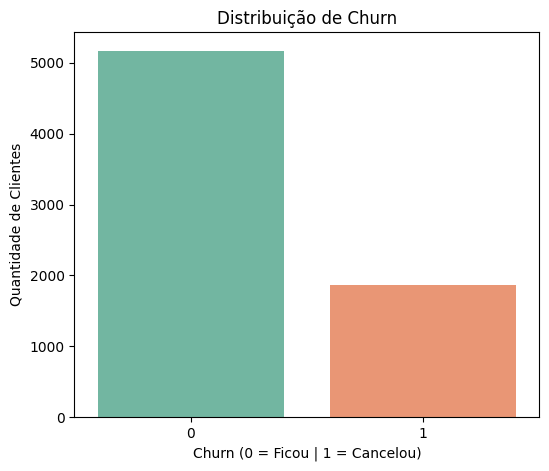

In [20]:
# Contagem e proporção
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print(churn_counts)
print(churn_pct.round(2))

# Gráfico
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='Churn', hue='Churn', palette='Set2', legend=False)
plt.title('Distribuição de Churn')
plt.xlabel('Churn (0 = Ficou | 1 = Cancelou)')
plt.ylabel('Quantidade de Clientes')
plt.show()

#### Churn por variáveis categóricas

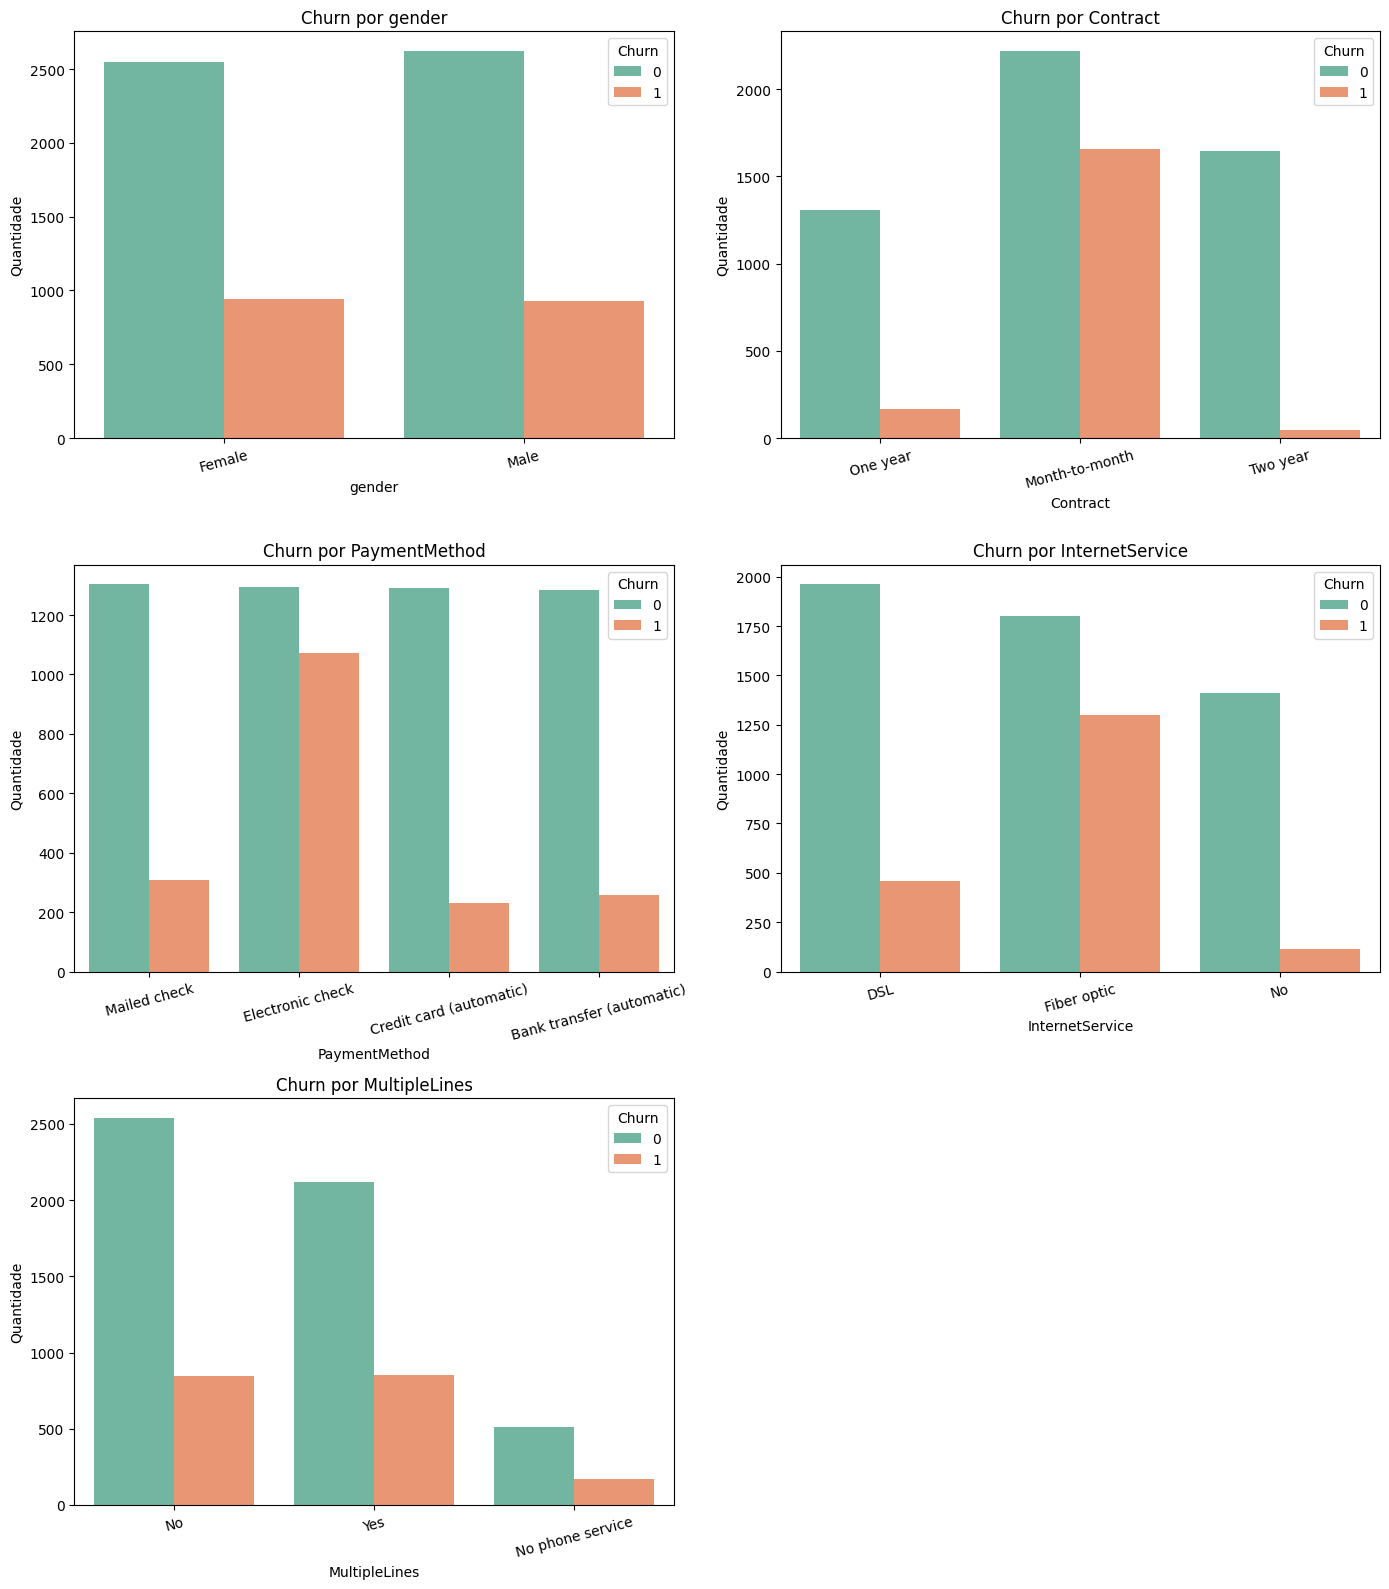

In [21]:
categoricas = ['gender', 'Contract', 'PaymentMethod', 'InternetService', 'MultipleLines']

fig, axes = plt.subplots(3, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(categoricas):
    sns.countplot(data=df, x=col, hue='Churn', palette='Set2', ax=axes[i])
    axes[i].set_title(f'Churn por {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Quantidade')
    axes[i].tick_params(axis='x', rotation=15)

# Remover o subplot vazio
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

#### Observações

#### Gender
- Cancelamento praticamente igual entre homens e mulheres.
- **Gênero não parece ser um fator relevante** para o churn.

#### Contract
- Clientes com contrato `Month-to-month` cancelam **muito mais**, quase metade cancela.
- Contratos `One year` e `Two year` têm churn quase nulo.
- **Tipo de contrato é um dos fatores mais críticos para a evasão.**

#### PaymentMethod
- `Electronic check` se destaca com churn muito alto comparado aos outros métodos.
- Métodos automáticos (`Credit card`, `Bank transfer`) têm churn bem menor.
- **A forma de pagamento está associada à evasão.**

#### InternetService
- `Fiber optic` tem churn proporcionalmente alto: quase 1 em cada 2 clientes cancela.
- `DSL` e clientes sem internet têm churn bem menor.
- **Clientes de fibra ótica parecem estar mais insatisfeitos com o serviço.**

#### MultipleLines
- Distribuição de churn parecida entre quem tem e quem não tem múltiplas linhas.
- **MultipleLines não parece influenciar o cancelamento.**

#### Churn por variáveis numéricas

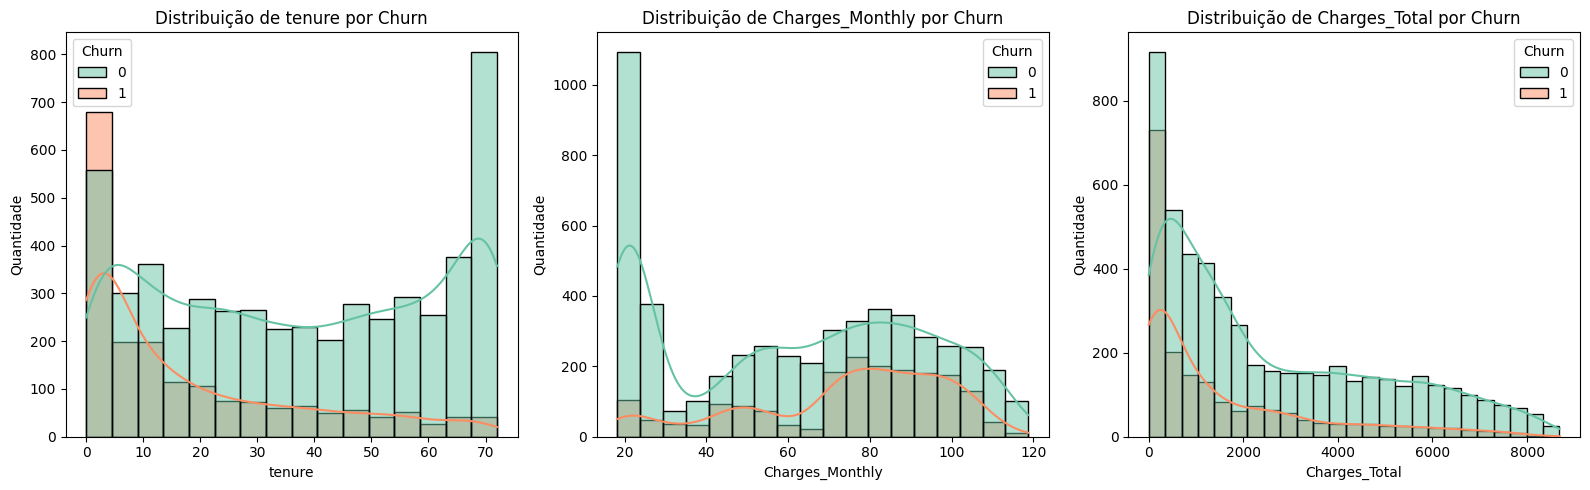

In [22]:
numericas = ['tenure', 'Charges_Monthly', 'Charges_Total']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(numericas):
    sns.histplot(data=df, x=col, hue='Churn', palette='Set2', kde=True, ax=axes[i])
    axes[i].set_title(f'Distribuição de {col} por Churn')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Quantidade')

plt.tight_layout()
plt.show()

#### Observações

#### Tenure
- Clientes que cancelaram se concentram fortemente nos **primeiros meses** de contrato.
- Clientes antigos (60+ meses) raramente cancelam.
- **Quanto menor o tempo de contrato, maior o risco de churn.**

#### Charges_Monthly
- Clientes que cancelaram tendem a pagar **valores mensais mais altos** (concentração entre R$70-100).
- **Cobranças mensais elevadas estão associadas ao cancelamento.**

#### Charges_Total
- Clientes que cancelaram têm total gasto **baixo**, reforça o padrão do tenure.
- Clientes com alto total gasto raramente cancelam.
- **Clientes novos que ainda gastaram pouco são os mais vulneráveis à evasão.**

## Relatório Final: Análise de Evasão de Clientes (Telecom X)

### Contexto
A Telecom X enfrenta uma taxa de evasão de **26.54%** — ou seja, 1 em cada 4 clientes cancela o serviço. Este relatório resume os principais fatores identificados na análise exploratória.

---

### Perfil Geral da Base
- **7.043 clientes** analisados após limpeza dos dados
- **26.54%** de taxa de churn (1.869 clientes cancelaram)
- Tempo médio de contrato: **32 meses**
- Cobrança mensal média: **64,76 reais**
- Total médio gasto por cliente: **2.279 reais**

---

### Principais Fatores Associados à Evasão

#### 1. Tipo de Contrato
Clientes com contrato `Month-to-month` apresentam churn muito superior aos demais.
Contratos anuais e bianuais estão fortemente associados à retenção.
> **Recomendação:** Incentivar a migração para contratos de maior duração com benefícios ou descontos.

#### 2. Serviço de Internet
Clientes com `Fiber optic` apresentam churn proporcionalmente alto: quase 1 em cada 2 cancela.
Pode indicar insatisfação com qualidade ou custo-benefício do serviço.
> **Recomendação:** Investigar a satisfação dos clientes de fibra ótica e revisar precificação ou qualidade.

#### 3. Método de Pagamento
Clientes que pagam via `Electronic check` cancelam muito mais do que os que usam métodos automáticos.
> **Recomendação:** Incentivar a migração para pagamentos automáticos com campanhas direcionadas.

#### 4. Tempo de Contrato (Tenure)
Clientes nos primeiros meses são os mais vulneráveis ao cancelamento.
Após 12 meses, a taxa de churn cai significativamente.
> **Recomendação:** Criar programas de onboarding e acompanhamento nos primeiros 3 meses de contrato.

#### 5. Cobrança Mensal
Clientes com cobranças mensais mais altas (R$70-100) têm maior tendência ao cancelamento.
> **Recomendação:** Avaliar planos e pacotes para clientes de alto valor, oferecendo benefícios que justifiquem o custo.

---

### Fatores Sem Impacto Relevante
- **Gênero**: distribuição de churn praticamente igual entre homens e mulheres
- **MultipleLines**: não demonstrou influência significativa no cancelamento
